# Speciation Change Comparison
This notebook compares the sample activity plots from baby run 5 and baby run 7 to show speciation changes due to salt chemistry.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Import tritium-specific libraries and units
from libra_toolbox.tritium.plotting import (
    ureg,
    plot_bars,
    plot_irradiation,
)

# Set matplotlib formatting
ureg.mpl_formatter = "{:~P}"

# Create output directory for saving plots
output_dir = Path("speciation_comparison")
output_dir.mkdir(exist_ok=True)

In [9]:
# Load data from baby run 5
from baby_run_5 import (
    baby_model as baby_model_5,
    measurements_after_background_sub as measurements_5,
    replacement_times as replacement_times_5
)

# Load data from baby run 7  
from baby_run_7 import (
    baby_model as baby_model_7,
    measurements_after_background_sub as measurements_7,
    replacement_times as replacement_times_7
)

print("Data loaded successfully!")
print(f"Run 5 - Number of measurement points: {len(replacement_times_5)}")
print(f"Run 7 - Number of measurement points: {len(replacement_times_7)}")

Data loaded successfully!
Run 5 - Number of measurement points: 7
Run 7 - Number of measurement points: 9


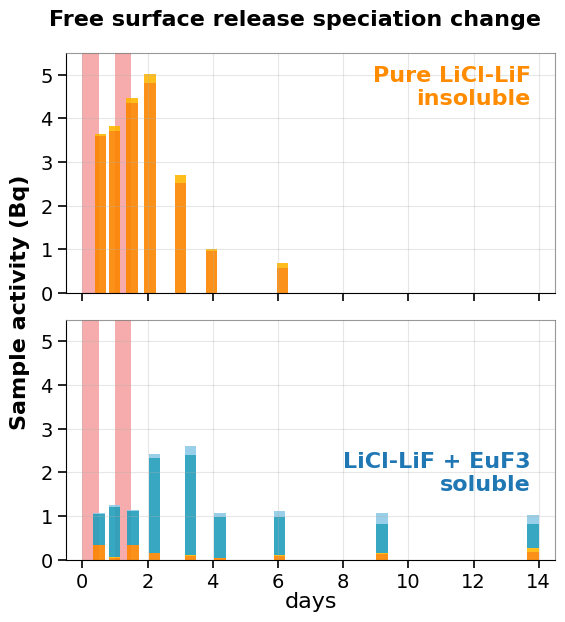

Combined plot saved successfully!


In [54]:
# Close all previous figures
plt.close('all')

# Create figure with two vertically stacked subplots sharing x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5.5, 6.5), facecolor='none', sharex=True)

# Plot Run 5 data in top subplot
plt.sca(ax1)
plot_bars(
    measurements_5,
    index=[time.to(ureg.day) for time in replacement_times_5]
)

# Set alpha for bars in top plot
for bar in ax1.patches:
    bar.set_alpha(0.9)

# Add irradiation bands to top plot
plot_irradiation(baby_model_5, facecolor="#EF5B5B", alpha=0.5, zorder=0)

# Plot Run 7 data in bottom subplot  
plt.sca(ax2)
plot_bars(
    measurements_7,
    index=[time.to(ureg.day) for time in replacement_times_7]
)

# Set alpha for bars in bottom plot
for bar in ax2.patches:
    bar.set_alpha(0.9)

# Add irradiation bands to bottom plot
plot_irradiation(baby_model_7, facecolor="#EF5B5B", alpha=0.5, zorder=0)

# Format both subplots with same specifications
for ax in [ax1, ax2]:
    # Set y-axis limits (same as run 5)
    ax.set_ylim(0, 5.5)
    
    # Explicitly remove any y-axis labels that may have been set by plot_bars
    ax.set_ylabel('')
    
    # Set x-axis limits
    ax.set_xlim(-0.5, 14.5)
    
    # Major tick marks only, pointing outside
    ax.tick_params(axis='both', which='major', length=6, width=1.2, direction='out', labelsize=14)
    ax.tick_params(axis='both', which='minor', length=0)  # disable minor ticks
    
    # Grid and spines
    ax.grid(True, axis="both", alpha=0.3)
    
    # Make all spines visible
    for spine in ["right", "top", "left", "bottom"]:
        ax.spines[spine].set_visible(True)
    
    # Style top and right spines gray with alpha 0.8
    ax.spines["top"].set_color('gray')
    ax.spines["top"].set_alpha(0.8)
    ax.spines["right"].set_color('gray')
    ax.spines["right"].set_alpha(0.8)

# Add a single centered y-label for the entire figure (much closer to plots)
fig.text(0.000, 0.5, "Sample activity (Bq)", fontsize=16, weight='bold', 
         rotation=90, va='center', ha='center')

# Set x-axis label only on bottom plot (size 16, not bold)
ax2.set_xlabel("days", fontsize=16, labelpad=0)

# Add main title (bold, 16pt, centered) with more spacing
fig.suptitle("Free surface release speciation change", fontsize=16, weight='bold', y=0.95)

# Add annotations in top right corners
# Top plot annotation (Run 5 - Pure reducing)
ax1.text(0.95, 0.95, "Pure LiCl-LiF\ninsoluble", 
         transform=ax1.transAxes, fontsize=16, weight='bold',
         ha='right', va='top', color='darkorange')

# Bottom plot annotation (Run 7 - Oxidizing with EuF3)
ax2.text(0.95, 0.45, "LiCl-LiF + EuF3\nsoluble", 
         transform=ax2.transAxes, fontsize=16, weight='bold',
         ha='right', va='top', color='tab:blue')

# Adjust layout for better spacing (minimal left padding now)
plt.tight_layout(rect=[0.01, 0, 1, 0.96])

# Display the plot
plt.show()

# Save the combined plot in multiple formats
fig.savefig("speciation_comparison/speciation_change_comparison.svg", format="svg", dpi=300, transparent=True)
fig.savefig("speciation_comparison/speciation_change_comparison.pdf", format="pdf", dpi=300, transparent=True)
fig.savefig("speciation_comparison/speciation_change_comparison.png", format="png", dpi=300, transparent=True)

print("Combined plot saved successfully!")